In [1]:
pip install tensorflow

  Using cached tensorflow-2.20.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.5 kB)
  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.9.23-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-manylinux2010_x86_64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-6.33.1-cp39-abi3-manylinux2014_x86_64.whl.metadata (593 bytes)
  Using cached termcolor-3.2.0-py3-none-any.whl.metadata (6.4 kB)
  Using cached wrapt-2.0.1-cp311-cp311-manylinux1_x86_64.manylinux_2_28_x86_64.manylinux_2_5_x86_64.whl.metadata (9.0 kB)
  Using cached grpcio-1.76.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (3.7 kB)
  Using ca

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras import layers, models

2025-12-03 02:32:47.902737: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-03 02:32:47.908939: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-03 02:32:48.170770: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-03 02:32:50.297406: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [4]:
# 1. LOAD DATA

df = pd.read_csv("heart_disease_data.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
# 2. CHECK FOR MISSING VALUES

print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [6]:
# 3. SPLIT FEATURES & TARGET

X = df.drop("target", axis=1)
y = df["target"]

In [7]:
# 4. TRAIN/TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
# 5. NORMALIZE / SCALE VALUES

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# 6. BUILD ANN MODEL

model = models.Sequential([
    layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/opt/conda/lib/python3.11/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-12-03 02:36:54.629745: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# 7. TRAIN THE MODEL

history = model.fit(
    X_train_scaled, 
    y_train, 
    epochs=50, 
    batch_size=16, 
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6736 - loss: 0.6346 - val_accuracy: 0.7347 - val_loss: 0.5621
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7254 - loss: 0.5811 - val_accuracy: 0.7551 - val_loss: 0.5077
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7047 - loss: 0.5716 - val_accuracy: 0.7959 - val_loss: 0.4743
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7876 - loss: 0.5003 - val_accuracy: 0.7959 - val_loss: 0.4424
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7772 - loss: 0.5200 - val_accuracy: 0.7959 - val_loss: 0.4279
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7617 - loss: 0.5275 - val_accuracy: 0.8163 - val_loss: 0.4175
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8187 - loss: 0.4701 - val_accuracy: 0.8163 - val_loss: 0.4049
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7772 - loss: 0.4639 - val_accuracy: 0.8163 - val_loss

In [11]:
# 8. EVALUATE MODEL

test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print("Test Accuracy:", test_acc)

Test Accuracy: 0.7704917788505554


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


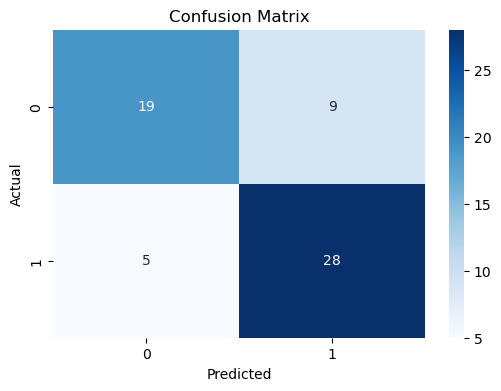

In [12]:
# 9. CONFUSION MATRIX

y_pred = (model.predict(X_test_scaled) > 0.5).astype("int32")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

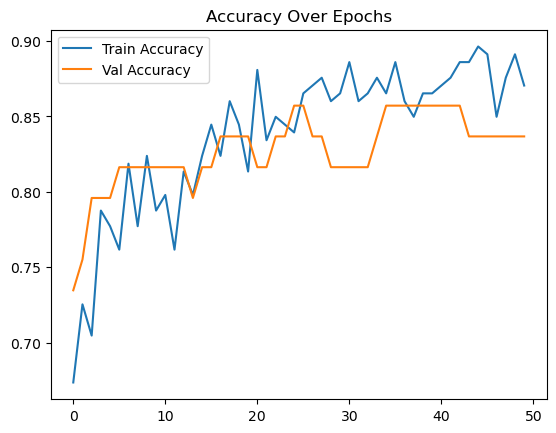

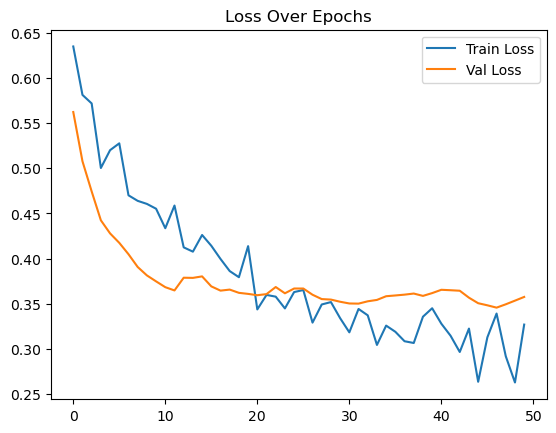

In [13]:
# 10. TRAINING CURVES

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy Over Epochs")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Over Epochs")
plt.show()

In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.68      0.73        28
           1       0.76      0.85      0.80        33

    accuracy                           0.77        61
   macro avg       0.77      0.76      0.77        61
weighted avg       0.77      0.77      0.77        61



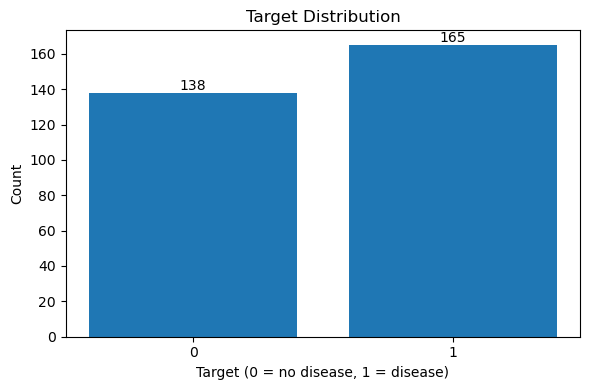

In [15]:
plt.figure(figsize=(6,4))
counts = df['target'].value_counts().sort_index()
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel('Target (0 = no disease, 1 = disease)')
plt.ylabel('Count')
plt.title('Target Distribution')
for i, v in enumerate(counts.values):
    plt.text(i, v + max(counts.values)*0.01, str(v), ha='center')
plt.tight_layout()
plt.show()

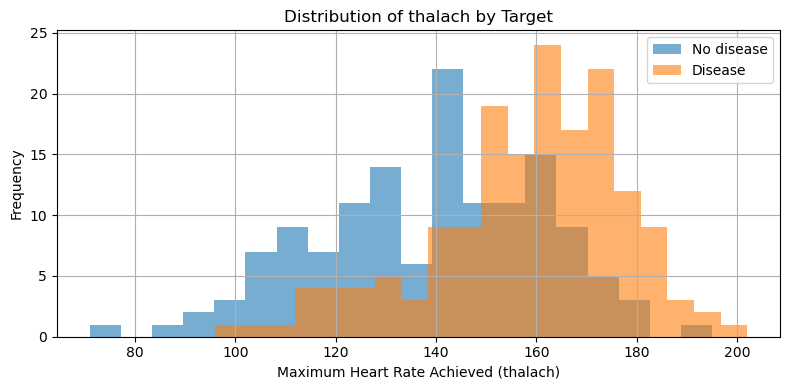

In [16]:
plt.figure(figsize=(8,4))
df[df['target']==0]['thalach'].hist(alpha=0.6, bins=20, label='No disease')
df[df['target']==1]['thalach'].hist(alpha=0.6, bins=20, label='Disease')
plt.xlabel('Maximum Heart Rate Achieved (thalach)')
plt.ylabel('Frequency')
plt.title('Distribution of thalach by Target')
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_578/2861847462.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_no, data_yes], labels=['No disease','Disease'])


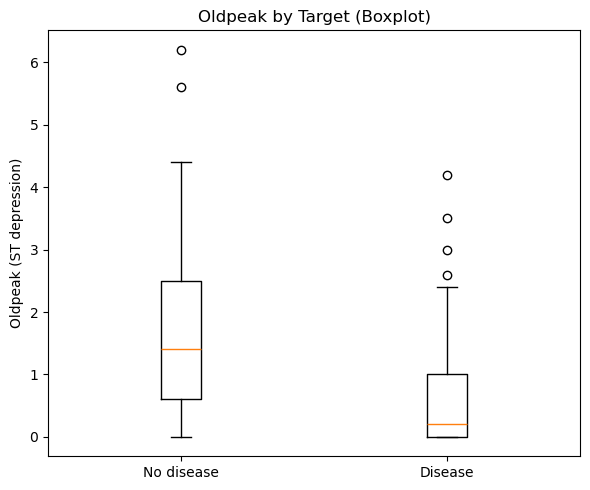

In [17]:
# ---- 3) oldpeak boxplot by target ----
plt.figure(figsize=(6,5))
data_no = df[df['target']==0]['oldpeak'].values
data_yes = df[df['target']==1]['oldpeak'].values
plt.boxplot([data_no, data_yes], labels=['No disease','Disease'])
plt.ylabel('Oldpeak (ST depression)')
plt.title('Oldpeak by Target (Boxplot)')
plt.tight_layout()
plt.show()

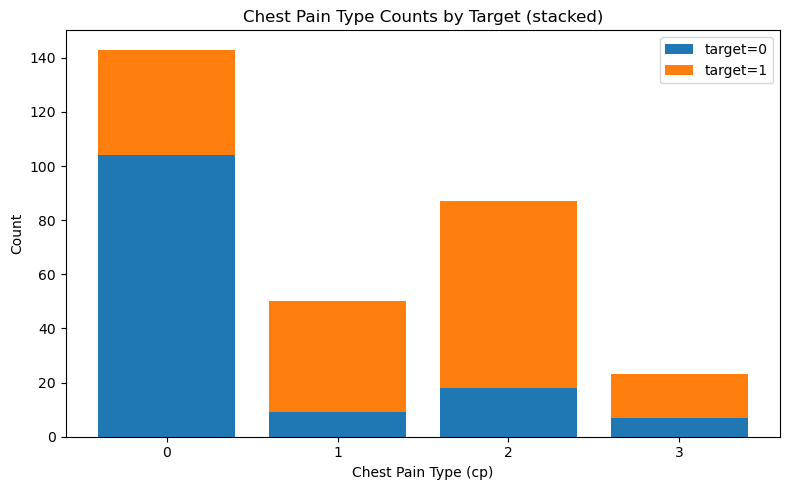

In [18]:
# ---- 4) Chest pain type (cp) stacked counts by target ----
cp_counts = df.groupby(['cp','target']).size().unstack(fill_value=0)
cp_indices = cp_counts.index.astype(str)
plt.figure(figsize=(8,5))
bottom = np.zeros(len(cp_counts))
for t in cp_counts.columns:
    vals = cp_counts[t].values
    plt.bar(cp_indices, vals, bottom=bottom, label=f"target={t}")
    bottom += vals
plt.xlabel('Chest Pain Type (cp)')
plt.ylabel('Count')
plt.title('Chest Pain Type Counts by Target (stacked)')
plt.legend()
plt.tight_layout()
plt.show()

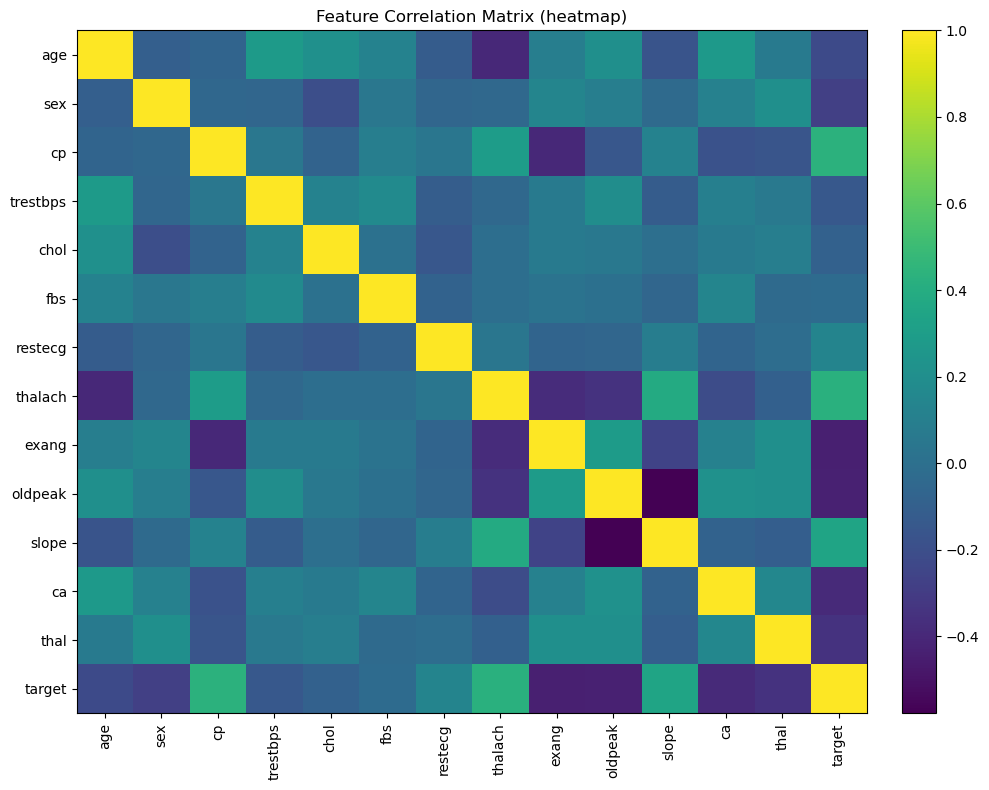

In [19]:
features = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal','target']
corr = df[features].corr()
plt.figure(figsize=(10,8))
im = plt.imshow(corr.values, aspect='auto')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(ticks=np.arange(len(features)), labels=features, rotation=90)
plt.yticks(ticks=np.arange(len(features)), labels=features)
plt.title('Feature Correlation Matrix (heatmap)')
plt.tight_layout()
plt.show()

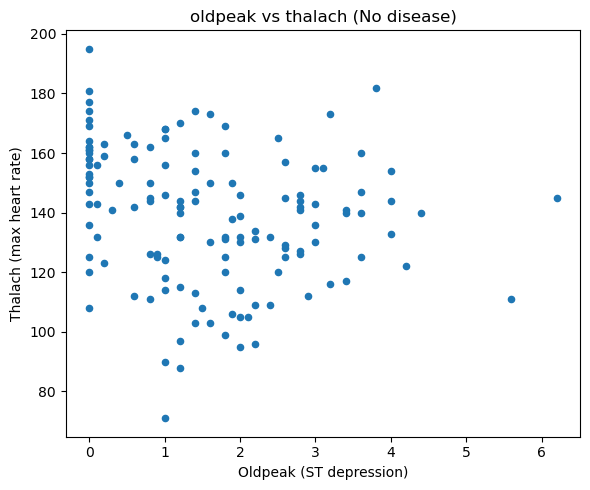

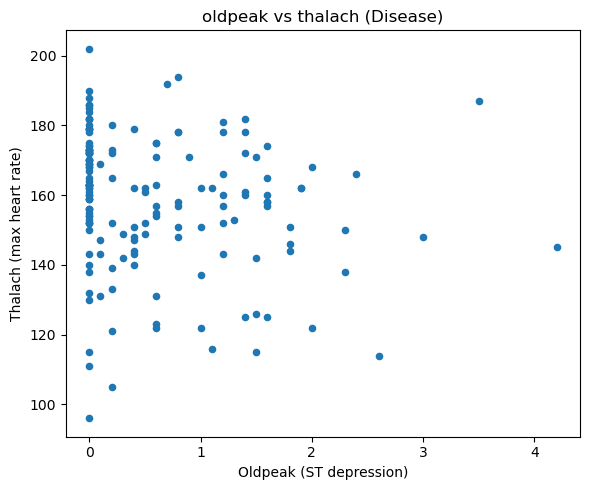

In [21]:
plt.figure(figsize=(6,5))
subset0 = df[df['target']==0]
plt.scatter(subset0['oldpeak'], subset0['thalach'], s=20)
plt.xlabel('Oldpeak (ST depression)')
plt.ylabel('Thalach (max heart rate)')
plt.title('oldpeak vs thalach (No disease)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,5))
subset1 = df[df['target']==1]
plt.scatter(subset1['oldpeak'], subset1['thalach'], s=20)
plt.xlabel('Oldpeak (ST depression)')
plt.ylabel('Thalach (max heart rate)')
plt.title('oldpeak vs thalach (Disease)')
plt.tight_layout()
plt.show()